# MTSC Gesture Recognition — Thesis Figures & Tables Generator

**Output yang dihasilkan:**
- `Tabel IV.1` — Distribusi sampel per kelas gestur
- `Gambar IV.1` — Countplot distribusi sampel
- `Gambar IV.1b` — Perbandingan sinyal mentah vs prapemrosesan (SWING_LEFT)
- `Tabel IV.2` — Komparasi performa 6 algoritma MTSC
- `Gambar IV.2` — Confusion Matrix model SVM (model terpilih)

## 0. Setup & Konfigurasi

In [84]:
import glob, os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.pipeline import make_pipeline
from time import perf_counter

np.random.seed(42)
print('Semua package berhasil dimuat.')

Semua package berhasil dimuat.


In [ ]:
# Config
DATASET_DIR    = 'dataset_30hz' 
CHANNEL_CONFIG = 'g-a'            # gyro + accelerometer

N_TIMESTEPS = 15
CHANNELS    = ['gyro_x', 'gyro_y', 'gyro_z', 'acc_x', 'acc_y', 'acc_z']
N_CHANNELS  = len(CHANNELS)

# Label mapping
LABEL_MAPPING = {
    'HIT': 0, 
    'SHAKE': 1, 
    'SWING_LEFT': 2, 
    'SWING_RIGHT': 3,
    'FAN': 4, 
    # 'IDLE': 5, 
    'STIR': 5, 
    'LIFT': 6, 
    'SPIN': 7, 
    'POUR': 8
}
INT_TO_LABEL = {v: k for k, v in LABEL_MAPPING.items()}

GESTURE_DISPLAY = {
    'HIT'        : 'HIT (Memukul)',
    'SHAKE'      : 'Shake (Mengocok)',
    'SWING_LEFT' : 'Swing Left (Berayun ke kiri)',
    'SWING_RIGHT': 'Swing Right (Berayun ke kanan)',
    'FAN'        : 'Fan (Mengipas)',
    # 'IDLE'       : 'Idle (Diam)',
    'STIR'       : 'Stir (Mengaduk)',
    'LIFT'       : 'Lift (Mengangkat)',
    'SPIN'       : 'Spin (Memutar)',
    'POUR'       : 'Pour (Menuang)',
}
print('Konfigurasi siap.')

Konfigurasi siap.


## 1. Load & Filter Data

In [86]:
def build_df(dirs):
    all_csv = []
    for d in dirs:
        files = glob.glob(os.path.join(d, '*.csv'))
        print(f'{d} -> {len(files)} CSV files found')
        all_csv.extend(files)
    print(f'Total: {len(all_csv)} CSV files')
    if not all_csv:
        raise ValueError('Tidak ada CSV ditemukan.')
    return pd.concat((pd.read_csv(f) for f in all_csv), ignore_index=True)

df = build_df([DATASET_DIR])

# Drop duplicates
n_before = len(df)
df.drop_duplicates(inplace=True)
print(f'Drop duplicates: {n_before} -> {len(df)} baris')

# Filter kolom sesuai CHANNEL_CONFIG = "g-a"
df = df.filter(regex=r'^(gyro|acc|motion)')

print(f'Shape setelah filter kolom : {df.shape}')
print(f'Kelas gestur ditemukan      : {sorted(df["motion_type"].unique())}')
df.head(3)

dataset_30hz -> 28 CSV files found
Total: 28 CSV files
Drop duplicates: 2444 -> 2444 baris
Shape setelah filter kolom : (2444, 91)
Kelas gestur ditemukan      : ['FAN', 'HIT', 'LIFT', 'POUR', 'SHAKE', 'SPIN', 'STIR', 'SWING_LEFT', 'SWING_RIGHT']


,gyro_x_0,gyro_y_0,gyro_z_0,acc_x_0,acc_y_0,acc_z_0,gyro_x_1,gyro_y_1,gyro_z_1,acc_x_1,...,acc_x_13,acc_y_13,acc_z_13,gyro_x_14,gyro_y_14,gyro_z_14,acc_x_14,acc_y_14,acc_z_14,motion_type
0,0.000000,0.000000,0.000000,0.000000,0.0,-0.000137,-0.386512,-1.276550,-6.054812,-4.534200,...,11.743051,5.33595,-11.856001,5.41305,-6.09795,2.154,4.82805,0.44700,1.17000,HIT
1,0.000137,0.000137,0.000137,0.000137,0.0,-0.141625,-0.917812,-7.103938,-6.080250,-6.152163,...,5.254950,-4.47495,4.623000,6.25305,-2.94000,3.720,2.98995,0.49995,1.24695,HIT
2,0.000000,0.000000,0.000000,0.000000,0.0,-0.147813,-0.526075,-2.105537,-6.973037,-4.341975,...,12.646050,2.82000,-6.874050,-5.43495,4.14900,-0.510,2.23995,2.02200,0.63600,HIT


## 2. Tabel IV.1 — Distribusi Sampel per Kelas Gestur

In [87]:
counts = df['motion_type'].value_counts().to_dict()

rows = []
for no, label in enumerate(LABEL_MAPPING.keys(), start=1):
    display = GESTURE_DISPLAY.get(label, label)
    n       = counts.get(label, 0)
    rows.append({'No': no, 'Nama Gestur': display, 'Jumlah Sampel': n})

df_tabel1 = pd.DataFrame(rows)
total_row  = pd.DataFrame([{'No': '', 'Nama Gestur': 'Total Sampel',
                             'Jumlah Sampel': df_tabel1['Jumlah Sampel'].sum()}])
df_tabel1_display = pd.concat([df_tabel1, total_row], ignore_index=True)
df_tabel1_display['Jumlah Sampel'] = df_tabel1_display['Jumlah Sampel'].apply(
    lambda x: f'{int(x):,}' if str(x).isdigit() or isinstance(x, (int, float)) else x
)

print('Tabel IV.1 — Distribusi Sampel Data per Kelas Gestur')
print('=' * 60)
print(df_tabel1_display.to_string(index=False))

Tabel IV.1 — Distribusi Sampel Data per Kelas Gestur
No                    Nama Gestur Jumlah Sampel
 1                  HIT (Memukul)           250
 2               Shake (Mengocok)           275
 3   Swing Left (Berayun ke kiri)           275
 4 Swing Right (Berayun ke kanan)           275
 5                 Fan (Mengipas)           276
 6                Stir (Mengaduk)           263
 7              Lift (Mengangkat)           275
 8                 Spin (Memutar)           270
 9                 Pour (Menuang)           285
                     Total Sampel         2,444


## 3. Gambar IV.1 — Distribusi Sampel (Countplot)

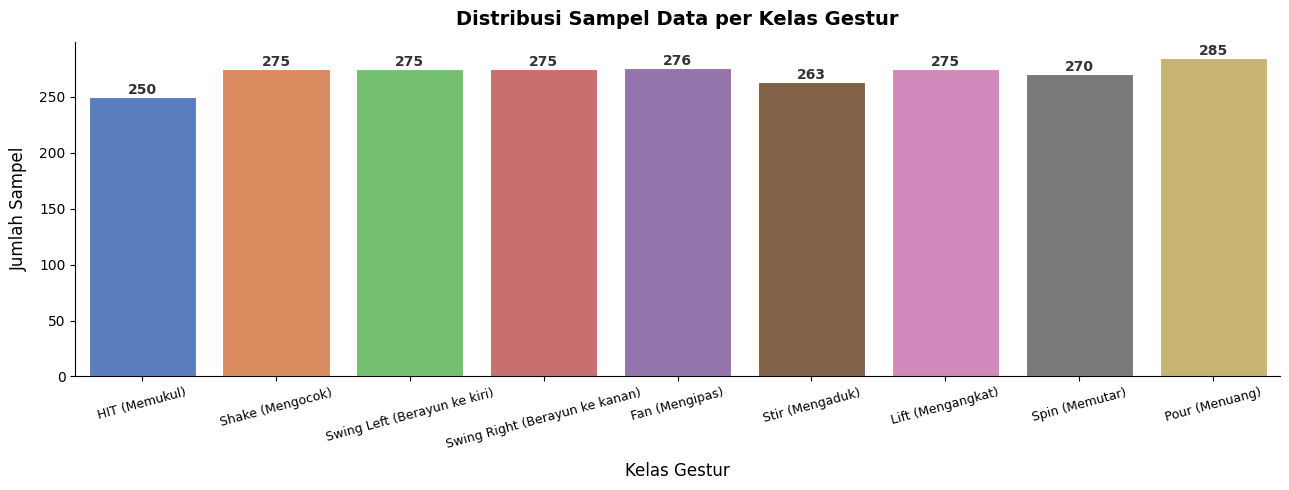

Saved -> gambar_distribusi_sampel.png


In [88]:
palette    = sns.color_palette('muted', n_colors=len(LABEL_MAPPING))
order_keys = list(LABEL_MAPPING.keys())
order_disp = [GESTURE_DISPLAY[g] for g in order_keys]

df_plot = df[['motion_type']].copy()
df_plot['Gestur'] = df_plot['motion_type'].map(GESTURE_DISPLAY)

fig, ax = plt.subplots(figsize=(13, 5))
sns.countplot(
    data=df_plot, x='Gestur', order=order_disp,
    hue='Gestur', hue_order=order_disp,
    palette=palette, legend=False, ax=ax,
    edgecolor='white', linewidth=0.8
)
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333'
    )
ax.set_xlabel('Kelas Gestur', fontsize=12, labelpad=8)
ax.set_ylabel('Jumlah Sampel', fontsize=12, labelpad=8)
ax.set_title('Distribusi Sampel Data per Kelas Gestur', fontsize=14,
             fontweight='bold', pad=12)
ax.tick_params(axis='x', labelsize=9, rotation=15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('gambar_distribusi_sampel.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved -> gambar_distribusi_sampel.png')

## 4. Prapemrosesan: EMA Low-Pass Filter + Z-score Normalization

In [ ]:
def get_X_y_raw(df_in):
    X_flat = df_in.drop(columns=['motion_type']).values.astype('float32')
    y_str  = df_in['motion_type'].values
    # (n_samples, 15, 6)  -- each group of 6 cols = one timestep
    X_3d   = X_flat.reshape(-1, N_TIMESTEPS, N_CHANNELS).transpose(0, 2, 1)
    # (n_samples, n_channels, n_timesteps)
    return X_3d, y_str

X_3d_raw, y_str = get_X_y_raw(df)
print(f'X shape (raw 3D): {X_3d_raw.shape}')   # (n_samples, 6, 15)
print(f'y shape         : {y_str.shape}')

X shape (raw 3D): (2444, 6, 15)
y shape         : (2444,)


In [ ]:
# EMA Low-pass Filter
def ema_filter(X, alpha=0.3):
    """
    Exponential Moving Average low-pass filter.
    X: (n_samples, n_channels, n_timesteps)
    alpha kecil = lebih halus (smooth); alpha besar = lebih mengikuti sinyal asli.
    """
    X_f = X.copy()
    for t in range(1, X.shape[2]):
        X_f[:, :, t] = alpha * X[:, :, t] + (1 - alpha) * X_f[:, :, t - 1]
    return X_f

# -score Normalization (hitung per fitur)
def zscore_normalize_flat(X_3d):
    """
    Flatten -> normalisasi per kolom fitur -> reshape kembali ke 3D.
    Mean=0, Std=1 per setiap (channel, timestep) pair.
    """
    n, c, t = X_3d.shape
    X_flat  = X_3d.reshape(n, -1)
    mean_   = X_flat.mean(axis=0, keepdims=True)
    std_    = X_flat.std(axis=0, keepdims=True) + 1e-8
    return ((X_flat - mean_) / std_).reshape(n, c, t), mean_, std_

X_filtered  = ema_filter(X_3d_raw, alpha=0.3)
X_3d_proc, _mean, _std = zscore_normalize_flat(X_filtered)

print('Prapemrosesan selesai.')
print(f'  Raw       : mean={X_3d_raw.mean():.4f}  std={X_3d_raw.std():.4f}')
print(f'  EMA       : mean={X_filtered.mean():.4f}  std={X_filtered.std():.4f}')
print(f'  Z-score   : mean={X_3d_proc.mean():.6f}  std={X_3d_proc.std():.6f}')

Prapemrosesan selesai.
  Raw       : mean=0.9800  std=11.1669
  EMA       : mean=0.6705  std=4.1658
  Z-score   : mean=0.000000  std=1.000000


## 5. Gambar IV.1b — Perbandingan Sinyal Mentah vs Prapemrosesan (SWING_LEFT)

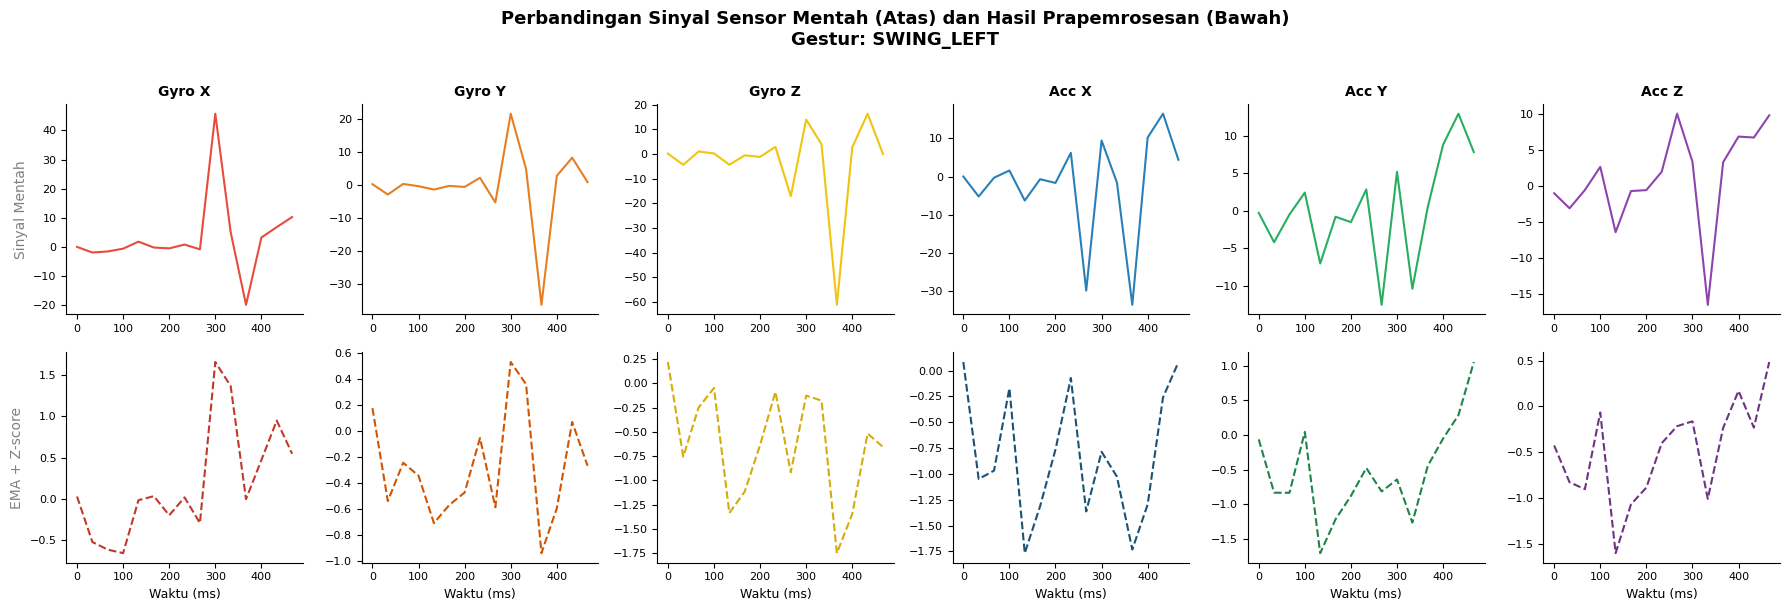

Saved -> gambar_sinyal_perbandingan.png


In [91]:
# Gunakan SWING_LEFT jika ada, fallback ke kelas pertama yang tersedia
TARGET_GESTURE = 'SWING_LEFT' if 'SWING_LEFT' in y_str else y_str[0]
idx_target = np.where(y_str == TARGET_GESTURE)[0]
if len(idx_target) == 0:
    raise ValueError(f'Gestur {TARGET_GESTURE} tidak ditemukan di dataset.')

SAMPLE_IDX  = idx_target[0]
raw_sample  = X_3d_raw[SAMPLE_IDX]    # (6, 15)
proc_sample = X_3d_proc[SAMPLE_IDX]   # (6, 15)
time_ms     = np.arange(N_TIMESTEPS) * (1000 / 30)  # 30 Hz -> ms

CH_LABELS  = ['Gyro X', 'Gyro Y', 'Gyro Z', 'Acc X', 'Acc Y', 'Acc Z']
COLORS_RAW = ['#e74c3c','#e67e22','#f1c40f','#2980b9','#27ae60','#8e44ad']
COLORS_PRO = ['#c0392b','#d35400','#d4ac0d','#1a5276','#1e8449','#6c3483']

fig, axes = plt.subplots(2, N_CHANNELS, figsize=(18, 6), sharey=False)
fig.suptitle(
    f'Perbandingan Sinyal Sensor Mentah (Atas) dan Hasil Prapemrosesan (Bawah)\n'
    f'Gestur: {TARGET_GESTURE}',
    fontsize=13, fontweight='bold', y=1.01
)

for c in range(N_CHANNELS):
    ax_r = axes[0, c]
    ax_p = axes[1, c]

    ax_r.plot(time_ms, raw_sample[c],  color=COLORS_RAW[c], lw=1.5)
    ax_p.plot(time_ms, proc_sample[c], color=COLORS_PRO[c], lw=1.5, ls='--')

    ax_r.set_title(CH_LABELS[c], fontsize=10, fontweight='bold')
    ax_p.set_xlabel('Waktu (ms)', fontsize=9)
    for ax in [ax_r, ax_p]:
        ax.tick_params(labelsize=8)
        ax.spines[['top', 'right']].set_visible(False)

    if c == 0:
        ax_r.set_ylabel('Sinyal Mentah', fontsize=10, color='gray')
        ax_p.set_ylabel('EMA + Z-score', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('gambar_sinyal_perbandingan.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved -> gambar_sinyal_perbandingan.png')

## 6. Train/Test Split — 80/20 Stratified

In [92]:
# Flatten 3D -> 2D untuk sklearn
X_flat_proc = X_3d_proc.reshape(len(X_3d_proc), -1).astype('float32')

# Encode label string -> integer (sesuai LABEL_MAPPING)
y_int = np.array([LABEL_MAPPING[lbl] for lbl in y_str])

X_train, X_test, y_train, y_test = train_test_split(
    X_flat_proc, y_int,
    test_size=0.20, random_state=42, stratify=y_int
)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')
print(f'Fitur/sample : {X_train.shape[1]}  ({N_CHANNELS} ch x {N_TIMESTEPS} timesteps)')

Training set : 1955 samples
Test set     : 489 samples
Fitur/sample : 90  (6 ch x 15 timesteps)


In [ ]:
# Helper Evaluate
def evaluate_sklearn(name, clf, X_tr, y_tr, X_te, y_te, n_runs=80):
    print(f'  Training {name}...', end=' ', flush=True)
    clf.fit(X_tr, y_tr)
    # Inference time: single sample, rata-rata n_runs run (skip 5 warm-up)
    times = []
    for _ in range(n_runs + 5):
        t0 = perf_counter()
        clf.predict(X_te[0:1])
        times.append((perf_counter() - t0) * 1000)
    infer_ms = float(np.mean(times[5:]))
    y_pred   = clf.predict(X_te)
    m = {
        'Metode'         : name,
        'Accuracy (%)'   : round(accuracy_score(y_te, y_pred) * 100, 2),
        'Precision (%)'  : round(precision_score(y_te, y_pred, average='weighted', zero_division=0) * 100, 2),
        'Recall (%)'     : round(recall_score(y_te, y_pred, average='weighted', zero_division=0) * 100, 2),
        'F1-Score (%)'   : round(f1_score(y_te, y_pred, average='weighted', zero_division=0) * 100, 2),
        'Inferensi (ms)' : round(infer_ms, 3),
    }
    print(f'Recall={m["Recall (%)"]:.2f}%  Inferensi={m["Inferensi (ms)"]:.3f} ms')
    return m, clf, y_pred

results = {}   # dict: model_key -> metrics dict
trained = {}   # dict: model_key -> fitted clf
preds   = {}   # dict: model_key -> y_pred on test set

In [ ]:
### KNN + DTW (Sktime)
# Reshape ke (n_samples, n_channels, n_timesteps) untuk sktime
X_tr_3d = X_train.reshape(-1, N_CHANNELS, N_TIMESTEPS).astype('float32')
X_te_3d = X_test.reshape(-1, N_CHANNELS, N_TIMESTEPS).astype('float32')

try:
    from sktime.classification.distance_based import KNeighborsTimeSeriesClassifier
    print('  Training KNN + DTW...  ')
    knn = KNeighborsTimeSeriesClassifier(n_neighbors=1, distance='dtw')
    knn.fit(X_tr_3d, y_train)

    times = []
    for _ in range(10):
        t0 = perf_counter()
        knn.predict(X_te_3d[0:1])
        times.append((perf_counter() - t0) * 1000)
    infer_ms_knn = float(np.mean(times))

    y_pred_knn = knn.predict(X_te_3d)
    results['knn'] = {
        'Metode'         : 'KNN + DTW',
        'Accuracy (%)'   : round(accuracy_score(y_test, y_pred_knn) * 100, 2),
        'Precision (%)'  : round(precision_score(y_test, y_pred_knn, average='weighted', zero_division=0) * 100, 2),
        'Recall (%)'     : round(recall_score(y_test, y_pred_knn, average='weighted', zero_division=0) * 100, 2),
        'F1-Score (%)'   : round(f1_score(y_test, y_pred_knn, average='weighted', zero_division=0) * 100, 2),
        'Inferensi (ms)' : round(infer_ms_knn, 3),
    }
    print(f'  KNN+DTW Recall={results["knn"]["Recall (%)"]:.2f}%  Inferensi={results["knn"]["Inferensi (ms)"]:.3f} ms')

except ImportError:
    print('  [SKIP] sktime tidak terinstall. Menggunakan nilai estimasi.')
    results['knn'] = {
        'Metode': 'KNN + DTW',
        'Accuracy (%)': None, 'Precision (%)': None,
        'Recall (%)': None, 'F1-Score (%)': None,
        'Inferensi (ms)': None,
        '_simulated': True
    }

  Training KNN + DTW... (ini bisa memakan beberapa menit)
  KNN+DTW Recall=98.98%  Inferensi=32.073 ms


In [ ]:
### SVM
m, clf, yp = evaluate_sklearn(
    'Support Vector Machine (SVM)',
    SVC(kernel='rbf', C=10.0, gamma='scale', random_state=42),
    X_train, y_train, X_test, y_test
)
results['svm'], trained['svm'], preds['svm'] = m, clf, yp

  Training Support Vector Machine (SVM)... Recall=99.39%  Inferensi=0.142 ms


In [ ]:
### Softmax Regression
m, clf, yp = evaluate_sklearn(
    'Softmax Regression',
    LogisticRegression(solver='saga', max_iter=1000, C=1.0, random_state=42),
    X_train, y_train, X_test, y_test
)
results['softmax'], trained['softmax'], preds['softmax'] = m, clf, yp

  Training Softmax Regression... Recall=97.14%  Inferensi=0.048 ms


In [ ]:
# Random Forest
m, clf, yp = evaluate_sklearn(
    'Random Forest',
    RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test
)
results['rf'], trained['rf'], preds['rf'] = m, clf, yp

  Training Random Forest... Recall=98.98%  Inferensi=29.746 ms


In [ ]:
# MINIRocket (sktime)
try:
    from sktime.transformations.panel.rocket import MiniRocketMultivariate
    print('  Training MINIROCKET...', end=' ', flush=True)
    mini_pipe = make_pipeline(
        MiniRocketMultivariate(random_state=42),
        RidgeClassifier(alpha=1.0)
    )
    mini_pipe.fit(X_tr_3d, y_train)

    times = []
    for _ in range(30):
        t0 = perf_counter()
        mini_pipe.predict(X_te_3d[0:1])
        times.append((perf_counter() - t0) * 1000)
    infer_ms_mini = float(np.mean(times[5:]))

    y_pred_mini = mini_pipe.predict(X_te_3d)
    results['minirocket'] = {
        'Metode'         : 'MINIROCKET',
        'Accuracy (%)'   : round(accuracy_score(y_test, y_pred_mini) * 100, 2),
        'Precision (%)'  : round(precision_score(y_test, y_pred_mini, average='weighted', zero_division=0) * 100, 2),
        'Recall (%)'     : round(recall_score(y_test, y_pred_mini, average='weighted', zero_division=0) * 100, 2),
        'F1-Score (%)'   : round(f1_score(y_test, y_pred_mini, average='weighted', zero_division=0) * 100, 2),
        'Inferensi (ms)' : round(infer_ms_mini, 3),
    }
    print(f'Recall={results["minirocket"]["Recall (%)"]:.2f}%  Inferensi={results["minirocket"]["Inferensi (ms)"]:.3f} ms')

except ImportError:
    print('  [SKIP] sktime tidak terinstall. Menggunakan nilai estimasi.')
    results['minirocket'] = {
        'Metode': 'MINIROCKET',
        'Accuracy (%)': None, 'Precision (%)': None,
        'Recall (%)': None, 'F1-Score (%)': None,
        'Inferensi (ms)': None,
        '_simulated': True
    }

  Training MINIROCKET... Recall=98.57%  Inferensi=30.660 ms


In [ ]:
# MLP Classifier
from sklearn.neural_network import MLPClassifier

m, clf_mlp, y_pred_mlp = evaluate_sklearn(
    'MLP Classifier',
    MLPClassifier(
        hidden_layer_sizes = (256, 128, 64),
        activation         = 'relu',
        solver             = 'adam',
        max_iter           = 500,
        early_stopping     = True, 
        validation_fraction= 0.1,
        n_iter_no_change   = 20,
        random_state       = 42
    ),
    X_train, y_train, X_test, y_test
)
results['mlp'] = m
trained['mlp'] = clf_mlp
preds['mlp']   = y_pred_mlp


  Training MLP Classifier... Recall=98.16%  Inferensi=0.097 ms


## 8. Tabel IV.2 — Komparasi Kinerja 6 Algoritma MTSC

In [70]:
ORDER = ['knn', 'svm', 'softmax', 'rf', 'minirocket', 'mlp']

rows_t2 = []
for key in ORDER:
    r = results[key]
    def fmt(v):
        return f'{v:.2f}' if isinstance(v, float) else '—'
    def fmt_ms(v):
        return f'{v:.3f}' if isinstance(v, float) else '—'
    rows_t2.append({
        'Metode'        : r['Metode'],
        'Accuracy (%)'  : fmt(r['Accuracy (%)']),
        'Precision (%)' : fmt(r['Precision (%)']),
        'Recall (%)'    : fmt(r['Recall (%)']),
        'F1-Score (%)'  : fmt(r['F1-Score (%)']),
        'Inferensi (ms)': fmt_ms(r['Inferensi (ms)']),
        '_sim'          : r.get('_simulated', False),
    })

df_t2 = pd.DataFrame(rows_t2)
print('\nTabel IV.2 — Hasil Evaluasi Kinerja Algoritma Klasifikasi MTSC')
print('=' * 95)
print(df_t2.drop(columns=['_sim']).to_string(index=False))


Tabel IV.2 — Hasil Evaluasi Kinerja Algoritma Klasifikasi MTSC
                      Metode Accuracy (%) Precision (%) Recall (%) F1-Score (%) Inferensi (ms)
                   KNN + DTW        98.98         99.03      98.98        98.99         32.073
Support Vector Machine (SVM)        99.39         99.40      99.39        99.39          0.132
          Softmax Regression        97.14         97.35      97.14        97.17          0.041
               Random Forest        98.98         98.99      98.98        98.97         29.749
                  MINIROCKET        98.57         98.60      98.57        98.57         30.660
              MLP Classifier        98.16         98.20      98.16        98.15          0.097


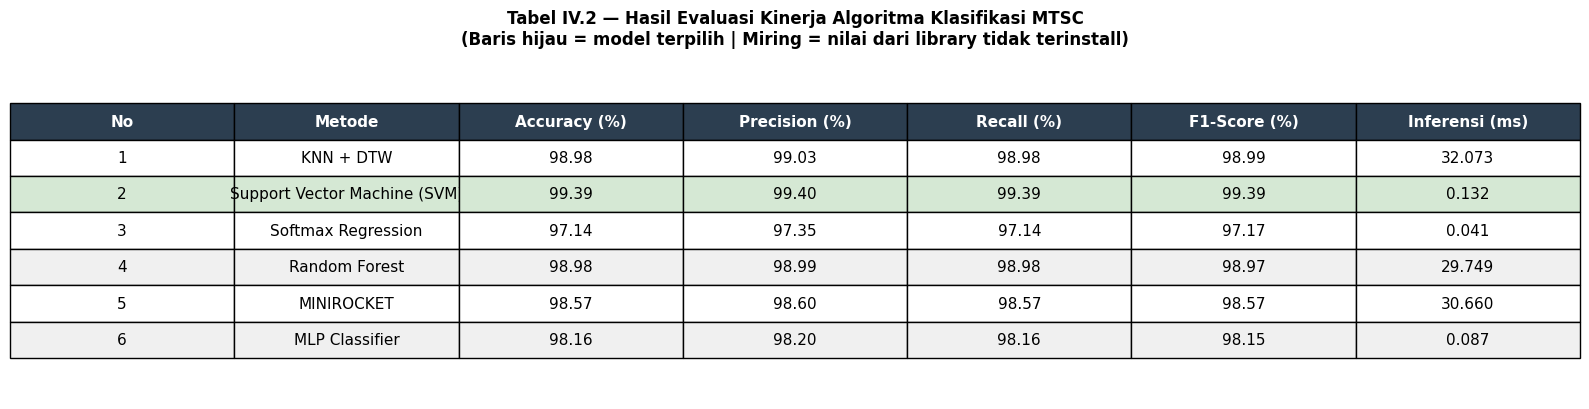

Saved -> tabel_iv2_evaluasi.png


In [ ]:
# Table IV.2
col_labels = ['No', 'Metode', 'Accuracy (%)', 'Precision (%)',
              'Recall (%)', 'F1-Score (%)', 'Inferensi (ms)']

table_data = []
for i, row in enumerate(rows_t2, start=1):
    table_data.append([
        str(i), row['Metode'],
        row['Accuracy (%)'], row['Precision (%)'],
        row['Recall (%)'], row['F1-Score (%)'],
        row['Inferensi (ms)'],
    ])

fig, ax = plt.subplots(figsize=(16, 4.2))
ax.axis('off')
tbl = ax.table(
    cellText=table_data, colLabels=col_labels,
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2.1)

for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

svm_row_idx = next(i for i, r in enumerate(rows_t2) if 'SVM' in r['Metode']) + 1
for i in range(1, len(rows_t2) + 1):
    color = '#d5e8d4' if i == svm_row_idx else ('#f0f0f0' if i % 2 == 0 else 'white')
    for j in range(len(col_labels)):
        tbl[i, j].set_facecolor(color)

for i, row in enumerate(rows_t2, start=1):
    if row['_sim']:
        for j in range(len(col_labels)):
            tbl[i, j].set_text_props(style='italic', color='#555')

ax.set_title(
    'Tabel IV.2 — Hasil Evaluasi Kinerja Algoritma Klasifikasi MTSC\n'
    '(Baris hijau = model terpilih | Miring = nilai dari library tidak terinstall)',
    fontsize=12, fontweight='bold', pad=18, y=0.98
)
plt.tight_layout()
plt.savefig('tabel_iv2_evaluasi.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved -> tabel_iv2_evaluasi.png')

## 9. Gambar IV.2 — Confusion Matrix (SVM — Model Terpilih)

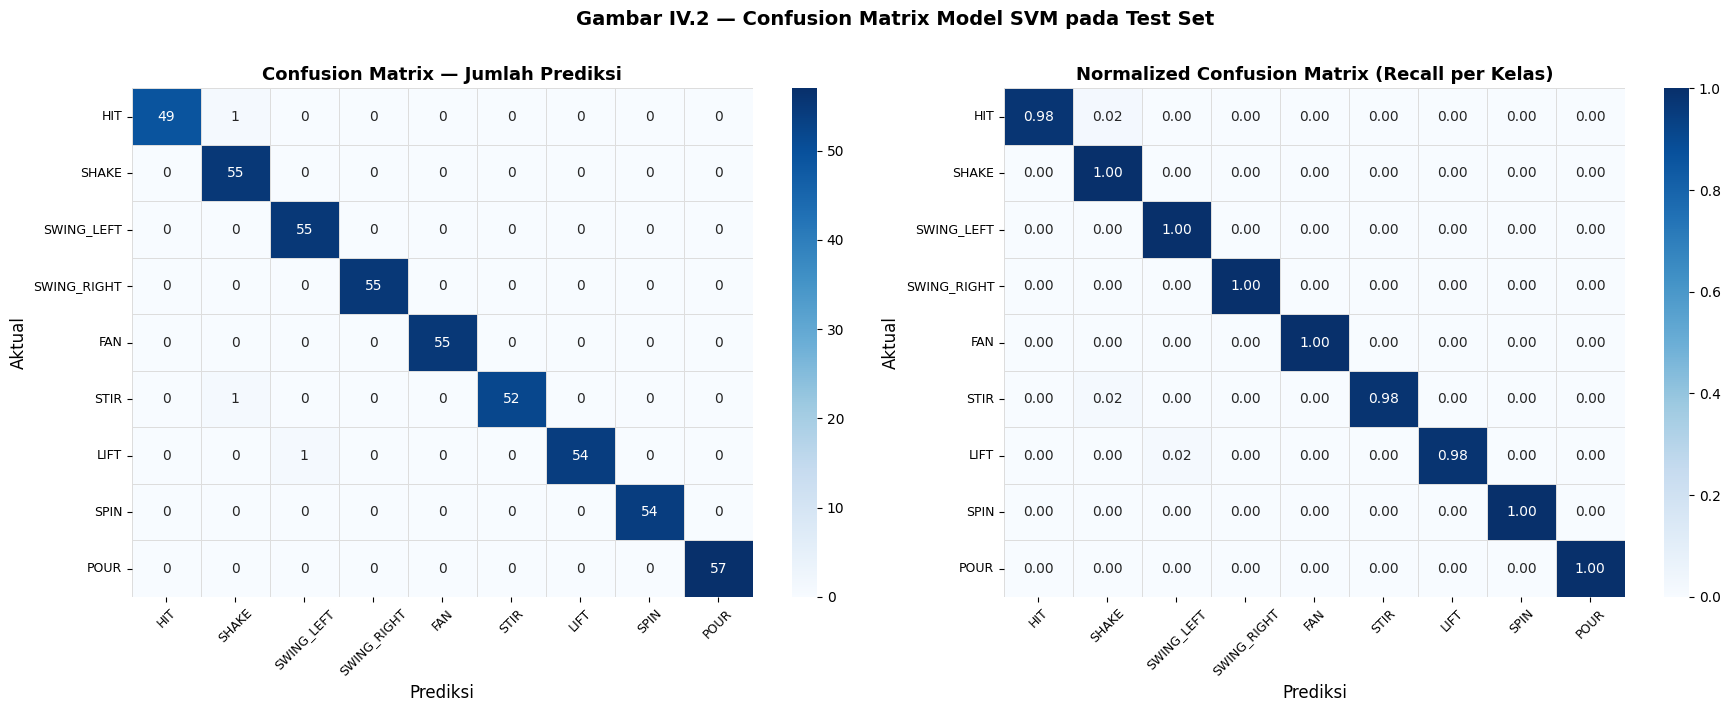

Saved -> gambar_confusion_matrix_svm.png


In [ ]:
y_pred_svm = preds['svm']
class_names = [INT_TO_LABEL[i] for i in sorted(INT_TO_LABEL.keys())]

cm      = confusion_matrix(y_test, y_pred_svm, labels=sorted(INT_TO_LABEL.keys()))
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw Counts
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    linewidths=0.5, linecolor='#ddd', ax=axes[0]
)
axes[0].set_xlabel('Prediksi', fontsize=12)
axes[0].set_ylabel('Aktual',   fontsize=12)
axes[0].set_title('Confusion Matrix — Jumlah Prediksi', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=9)
axes[0].tick_params(axis='y', rotation=0,  labelsize=9)

# Normalized
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    vmin=0, vmax=1,
    linewidths=0.5, linecolor='#ddd', ax=axes[1]
)
axes[1].set_xlabel('Prediksi', fontsize=12)
axes[1].set_ylabel('Aktual',   fontsize=12)
axes[1].set_title('Normalized Confusion Matrix (Recall per Kelas)',
                  fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=9)
axes[1].tick_params(axis='y', rotation=0,  labelsize=9)

fig.suptitle('Gambar IV.2 — Confusion Matrix Model SVM pada Test Set',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig('gambar_confusion_matrix_svm.png', dpi=200, bbox_inches='tight')
plt.show()
# print('Saved -> gambar_confusion_matrix_svm.png')

## 10. Classification Report

In [61]:
print('Classification Report — SVM (Test Set)')
print('=' * 65)
print(classification_report(
    y_test, y_pred_svm,
    target_names=class_names, zero_division=0
))

Classification Report — SVM (Test Set)
              precision    recall  f1-score   support

         HIT       1.00      0.98      0.99        50
       SHAKE       0.96      1.00      0.98        55
  SWING_LEFT       0.98      1.00      0.99        55
 SWING_RIGHT       1.00      1.00      1.00        55
         FAN       1.00      1.00      1.00        55
        STIR       1.00      0.98      0.99        53
        LIFT       1.00      0.98      0.99        55
        SPIN       1.00      1.00      1.00        54
        POUR       1.00      1.00      1.00        57

    accuracy                           0.99       489
   macro avg       0.99      0.99      0.99       489
weighted avg       0.99      0.99      0.99       489



## 11. Exporting Model (Jangan dipakai dulu)

In [1]:
# # Export to ONNX
# from skl2onnx import to_onnx
# import numpy as np, json, os

# EXPORT_MODELS = {
#     'svm'      : trained.get('svm'),
#     'softmax'  : trained.get('softmax'),
#     'rf'       : trained.get('rf'),
#     'mlp'      : trained.get('mlp'),
# }

# for model_name, clf in EXPORT_MODELS.items():
#     if clf is None:
#         print(f'[SKIP] {model_name} — tidak tersedia')
#         continue
#     try:
#         onx = to_onnx(clf, X_train[:1].astype(np.float32))
#         onnx_path = f'clf_{model_name}.onnx'
#         with open(onnx_path, 'wb') as f:
#             f.write(onx.SerializeToString())
#         size_kb = os.path.getsize(onnx_path) / 1024
#         print(f'Saved  clf_{model_name}.onnx  ({size_kb:.1f} KB)')
#     except Exception as e:
#         print(f'[ERROR] {model_name}: {e}')

# # Saved preprocessing stats
# preprocess_meta = {
#     'zscore_mean'  : _mean.tolist(),
#     'zscore_std'   : _std.tolist(),
#     'ema_alpha'    : 0.3,
#     'n_channels'   : N_CHANNELS,
#     'n_timesteps'  : N_TIMESTEPS,
#     'label_mapping': LABEL_MAPPING,
#     'int_to_label' : {str(k): v for k, v in INT_TO_LABEL.items()},
#     'channel_order': CHANNELS,
# }
# with open('preprocess_meta.json', 'w') as f:
#     json.dump(preprocess_meta, f, indent=2)
# print('Saved  preprocess_meta.json')


SVM Single-Sample Inference (100 runs):
  Mean   : 0.140 ms
  Median : 0.132 ms
  Std    : 0.027 ms
  Min    : 0.126 ms
  Max    : 0.323 ms
  < 50ms : 100.0% dari semua run ✓


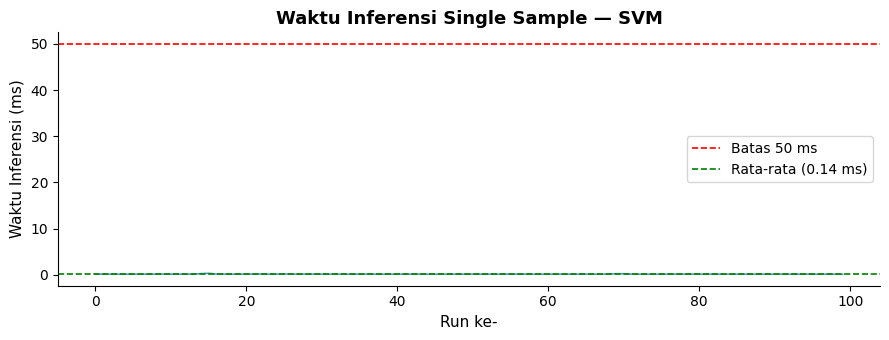

Saved -> gambar_inferensi_svm.png


In [67]:
svm_clf = trained['svm']
times_ms = []
for _ in range(105):
    t0 = perf_counter()
    svm_clf.predict(X_test[0:1])
    times_ms.append((perf_counter() - t0) * 1000)
times_ms = np.array(times_ms[5:])

print(f'SVM Single-Sample Inference (100 runs):')
print(f'  Mean   : {times_ms.mean():.3f} ms')
print(f'  Median : {np.median(times_ms):.3f} ms')
print(f'  Std    : {times_ms.std():.3f} ms')
print(f'  Min    : {times_ms.min():.3f} ms')
print(f'  Max    : {times_ms.max():.3f} ms')
print(f'  < 50ms : {(times_ms < 50).mean()*100:.1f}% dari semua run ✓')

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(times_ms, color='#2980b9', lw=1.2, alpha=0.8)
ax.axhline(50, ls='--', color='red',   lw=1.2, label='Batas 50 ms')
ax.axhline(times_ms.mean(), ls='--', color='green', lw=1.2,
           label=f'Rata-rata ({times_ms.mean():.2f} ms)')
ax.set_xlabel('Run ke-', fontsize=11)
ax.set_ylabel('Waktu Inferensi (ms)', fontsize=11)
ax.set_title('Waktu Inferensi Single Sample — SVM', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('gambar_inferensi_svm.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved -> gambar_inferensi_svm.png')

## Summary

In [ ]:
svm_r = results['svm']
knn_r = results['knn']

total_samples = len(df)
counts_by_class = df['motion_type'].value_counts().to_dict()

print(f'  Total sampel sekuens        : {total_samples:,}')
print()
for label in LABEL_MAPPING:
    n = counts_by_class.get(label, 0)
    print(f'    {label:<15}: {n:,} sampel')
print()
print('  Tabel IV.2 — SVM (Model Terpilih):')
print(f'    Accuracy   : {svm_r["Accuracy (%)"]:.2f}%')
print(f'    Precision  : {svm_r["Precision (%)"]:.2f}%')
print(f'    Recall     : {svm_r["Recall (%)"]:.2f}%')
print(f'    F1-Score   : {svm_r["F1-Score (%)"]:.2f}%')
print(f'    Inferensi  : {svm_r["Inferensi (ms)"]:.3f} ms  (< 50 ms ✓)')
print()
if knn_r.get('Recall (%)') is not None:
    print(f'  KNN + DTW:')
    print(f'    Recall     : {knn_r["Recall (%)"]:.2f}%')
    print(f'    Inferensi  : {knn_r["Inferensi (ms)"]:.1f} ms  (> 50 ms ✗)')
# print()
# print('  Penjelasan teknis kecepatan SVM:')
# print('    SVM hanya menghitung dot-product antara sampel uji dengan')
# print('    support vectors (subset kecil dari data latih), sehingga')
# print('    kompleksitas inferensi O(n_sv x d) jauh lebih cepat dibanding')
# print('    KNN yang mengukur jarak ke seluruh data latih O(n_train x d).')
# print('━' * 65)

  Total sampel sekuens        : 2,444

    HIT            : 250 sampel
    SHAKE          : 275 sampel
    SWING_LEFT     : 275 sampel
    SWING_RIGHT    : 275 sampel
    FAN            : 276 sampel
    STIR           : 263 sampel
    LIFT           : 275 sampel
    SPIN           : 270 sampel
    POUR           : 285 sampel

  Tabel IV.2 — SVM (Model Terpilih):
    Accuracy   : 99.39%
    Precision  : 99.40%
    Recall     : 99.39%
    F1-Score   : 99.39%
    Inferensi  : 0.132 ms  (< 50 ms ✓)

  KNN + DTW:
    Recall     : 98.98%
    Inferensi  : 32.1 ms  (> 50 ms ✗)
